# Integration with Harmony

In [1]:
# libraries
import os
import tempfile

import scanpy as sc
import seaborn as sns
import torch
import pickle
from pathlib import Path

Load the data

In [2]:
# setting paths
main_dir = Path('/Volumes/robin_work/cosmx_gray')
os.chdir(main_dir)

In [3]:
# load comb object
comb = sc.read_h5ad('data/comb/h5ad/comb_v0.h5ad')

In [4]:
comb.layers["counts"] = comb.X.copy()

In [5]:
sc.pp.normalize_total(comb)
sc.pp.log1p(comb)

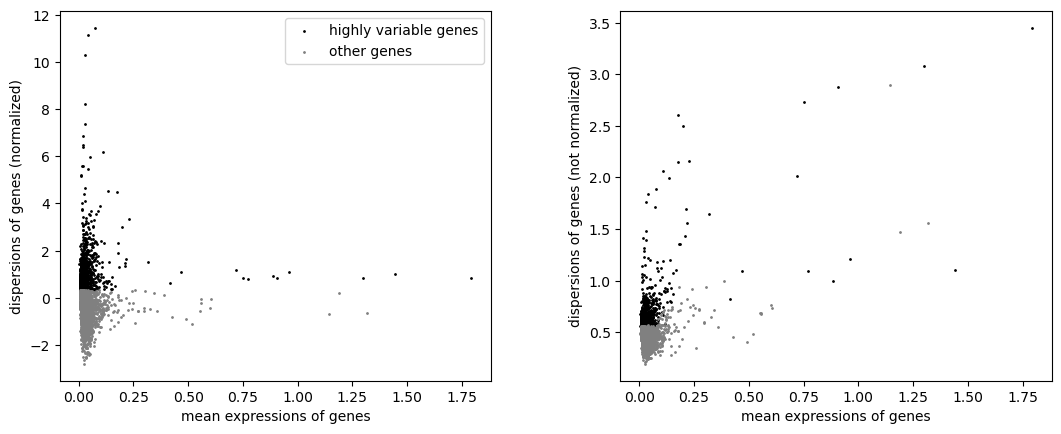

In [6]:
sc.pp.highly_variable_genes(comb, n_top_genes=2000, batch_key="slide_name")
sc.pl.highly_variable_genes(comb)

PCA calculation

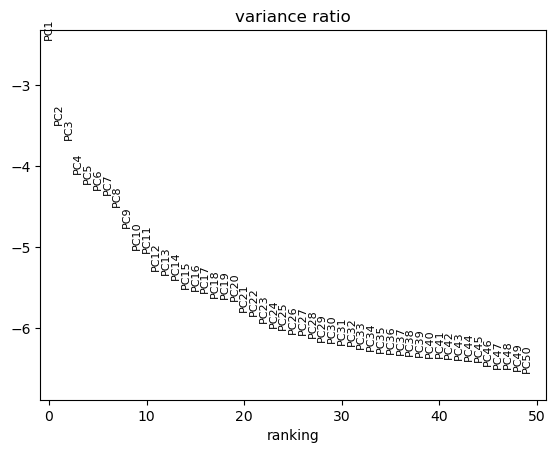

In [7]:
sc.pp.pca(comb, key_added='pca')
sc.pl.pca_variance_ratio(comb, n_pcs=50, log=True)

Neighbours and UMAP

In [ ]:
sc.pp.neighbors(
    comb,
    n_pcs=30,
    use_rep='pca',
    key_added='unintegrated'
)


In [19]:
sc.tl.umap(
    comb,
    key_added='umap',
    neighbors_key='unintegrated',
)

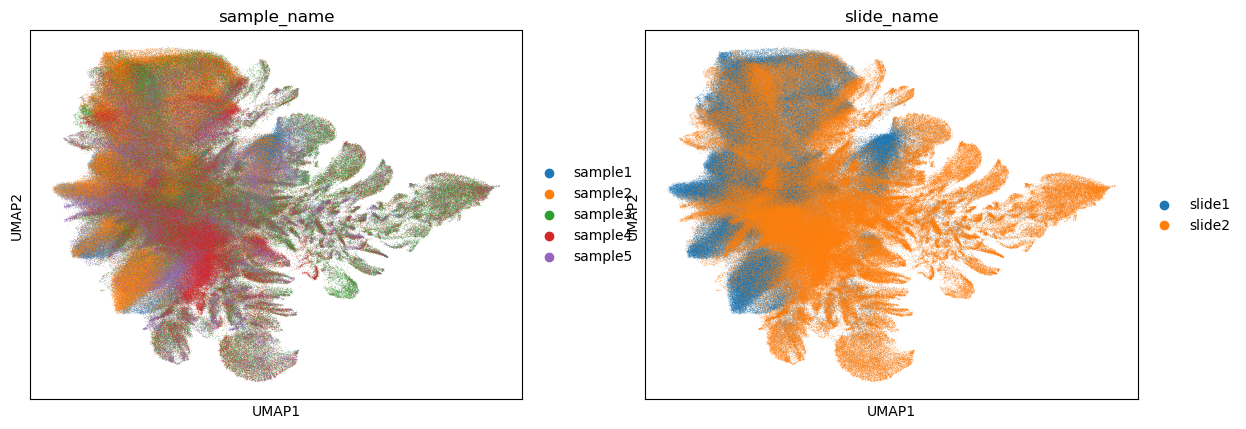

In [22]:
sc.pl.embedding(
    comb,
    basis = "umap",
    color=["sample_name", "slide_name"],
    size=0.5,
)

## Harmony PCS Correction

In [10]:
import harmonypy as hm


In [11]:
meta_data = comb.obs
vars_use = ['sample_name', 'slide_name']
data_mat = comb.obsm['X_pca']


ho = hm.run_harmony(
    data_mat=data_mat,
    meta_data=meta_data,
    vars_use=vars_use,
    theta=[1,1]
    )

2025-08-13 16:01:05,082 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-13 16:02:42,742 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-13 16:02:43,924 - harmonypy - INFO - Iteration 1 of 10
2025-08-13 16:04:49,792 - harmonypy - INFO - Iteration 2 of 10
2025-08-13 16:06:56,065 - harmonypy - INFO - Iteration 3 of 10
2025-08-13 16:09:03,685 - harmonypy - INFO - Iteration 4 of 10
2025-08-13 16:10:59,665 - harmonypy - INFO - Iteration 5 of 10
2025-08-13 16:12:45,616 - harmonypy - INFO - Iteration 6 of 10
2025-08-13 16:14:37,620 - harmonypy - INFO - Iteration 7 of 10
2025-08-13 16:16:23,145 - harmonypy - INFO - Iteration 8 of 10
2025-08-13 16:18:13,424 - harmonypy - INFO - Iteration 9 of 10
2025-08-13 16:20:21,437 - harmonypy - INFO - Iteration 10 of 10
2025-08-13 16:22:17,440 - harmonypy - INFO - Stopped before convergence


In [14]:
comb.obsm['X_pca']

array([[ 5.9052247e-01,  7.6406801e-01,  1.7007548e-01, ...,
        -2.5035845e-02, -3.0632713e-01, -1.0171164e-02],
       [-6.3156533e-01,  1.8387556e-02,  7.1559387e-01, ...,
         1.2852447e-01, -2.5364662e-02, -3.0985510e-02],
       [-9.4269508e-01,  5.1811762e-02, -2.7456331e-01, ...,
         1.5149105e-01,  5.5701829e-02,  4.0236831e-01],
       ...,
       [ 2.8347623e+00,  1.7594494e+00, -1.2926781e+00, ...,
        -9.7105149e-03,  1.7911356e-02, -4.7116958e-02],
       [ 5.2145686e+00, -9.3029541e-01, -1.5771651e+00, ...,
        -1.4428793e-01, -3.6160097e-01, -2.5240809e-01],
       [ 4.2521029e+00,  2.2934160e+00, -1.5777144e+00, ...,
        -8.0597796e-02,  2.9761225e-03,  2.4910326e-04]],
      shape=(814875, 50), dtype=float32)

In [ ]:
import numpy as np

Z = np.asarray(ho.Z_corr)

# If cells are on the wrong axis:
if Z.shape[1] == comb.n_obs:  
    Z = Z.T


In [32]:
# save Z
harmony_matrix_path = main_dir / 'data/comb/harmony_matrix.pkl'
with open(harmony_matrix_path, "wb") as f:
    pickle.dump(Z, f)

## Loading Harmony Matrix and Processing

In [8]:
harmony_matrix_path = main_dir / 'data/comb/harmony_matrix.pkl'

# read harmony matrix
with open(harmony_matrix_path, "rb") as f:
    Z = pickle.load(f)


comb.obsm['pca_harmony'] = Z

In [9]:
sc.pp.neighbors(
    comb,
    use_rep='pca_harmony',
    key_added = 'harmony'
    )

comb

/Users/robin.carvajal/miniforge3/envs/py-cosmx/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 814875 × 6175
    obs: 'fov', 'Area', 'AspectRatio', 'x_FOV_px', 'y_FOV_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID_numeric', 'x_slide_mm', 'y_slide_mm', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quant

In [10]:
sc.tl.umap(
    comb,
    neighbors_key='harmony',
    key_added='umap_harmony')

In [13]:
comb

AnnData object with n_obs × n_vars = 814875 × 6175
    obs: 'fov', 'Area', 'AspectRatio', 'x_FOV_px', 'y_FOV_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID_numeric', 'x_slide_mm', 'y_slide_mm', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quant

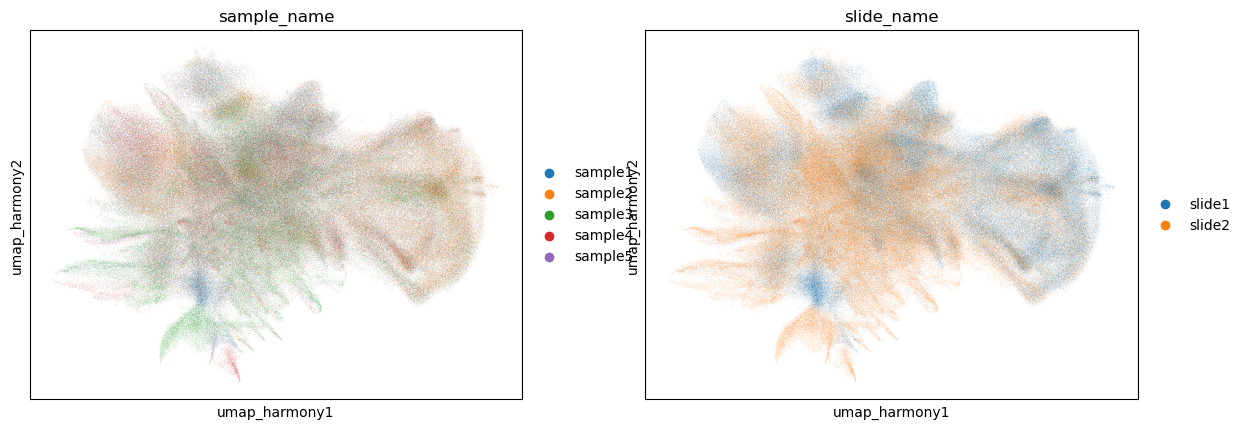

In [17]:
sc.pl.embedding(
    comb,
    basis = "umap_harmony",
    color=["sample_name", "slide_name"],
    size=0.1,
)